In [2]:
import sys
from pyprojroot import here

# Ritorna il percorso assoluto della root del progetto
PROJECT_ROOT = str(here()) + "/"
sys.path.append(PROJECT_ROOT)
sys.dont_write_bytecode = True

print(f"La root del progetto è: {PROJECT_ROOT}")

La root del progetto è: /home/cvalentino/SissaUnisaDraftCodes/


In [3]:
from paths import DRT_PATH, TP5_PATH

ABS_PATH = PROJECT_ROOT + DRT_PATH + TP5_PATH

model_name = "column.blend"
load_data_bound = ABS_PATH + "./files/data.csv"

fig_dir = "figures/"
bound_fig = ABS_PATH + fig_dir + "boundary_conditions.png"

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [12]:
df = pd.read_csv(load_data_bound, sep=";", index_col=0)

In [13]:
points = df.iloc[:, :3].values
x, y, z = points[:, 0], points[:, 1], points[:, 2]
u1 = df.iloc[:, 3].values
u2 = df.iloc[:, 4].values

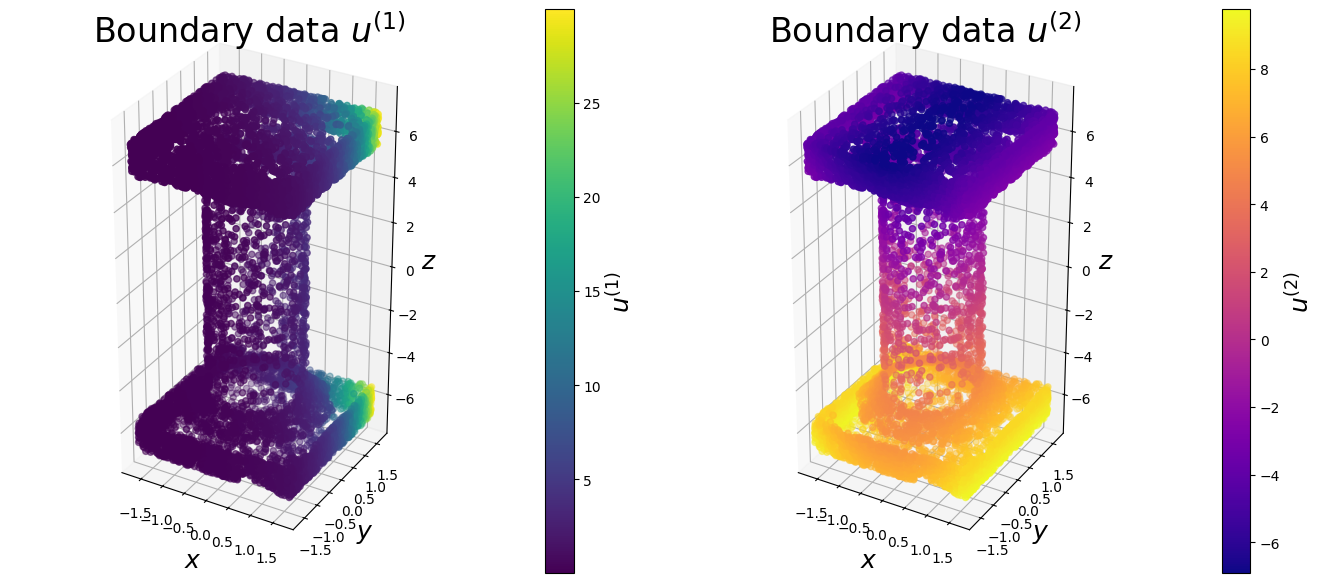

In [57]:
# Creazione della figura e dei subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 16), subplot_kw={'projection': '3d'})

# Scatter plot nei due subplot
sc1 = ax1.scatter(x, y, z, c=u1, cmap='viridis')
sc2 = ax2.scatter(x, y, z, c=u2, cmap='plasma')
ax1.set_box_aspect([1.5, 1.5, 3])
ax2.set_box_aspect([1.5, 1.5, 3])

# Creazione delle colorbar accanto ai rispettivi subplot
cbar1 = fig.colorbar(sc1, ax=ax1, fraction=0.05, pad=0.1, shrink=0.7)
cbar1.set_label('$u^{\left( 1 \\right)}$', fontsize=18)
cbar2 = fig.colorbar(sc2, ax=ax2, fraction=0.05, pad=0.1, shrink=0.7)
cbar2.set_label('$u^{\left( 2 \\right)}$', fontsize=18)

ax1.set_title("Boundary data $u^{\left( 1 \\right)}$", fontsize=24)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$y$")
ax1.set_zlabel("$z$")
ax2.set_title("Boundary data $u^{\left( 2 \\right)}$", fontsize=24)
ax2.set_xlabel("$x$")
ax2.set_ylabel("$y$")
ax2.set_zlabel("$z$")

for ax in [ax1, ax2]:
    ax.xaxis.label.set_size(18)
    ax.yaxis.label.set_size(18)
    ax.zaxis.label.set_size(18)
    ax.tick_params(axis='both', which='major', labelsize=10)
plt.savefig(bound_fig, transparent=True)
plt.show()